In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.nn import functional as F
import numpy as np
from generate_data import *
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from tqdm import tqdm
import pandas as pd
import pickle
import random
import matplotlib.pyplot as plt

In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# set random seed globally
seed = 0
set_seed(seed)

In [3]:
## label to group mapping

label_group_dict = {
    # label: group
    0:4,
    1:6,
    2:2,
    3:3,
    4:5,
    5:7
}

In [4]:
## placeholder for X, y

X = np.zeros((6000, 100))
y = np.zeros((6000, 1))

In [5]:
## generate fake data

group4s = generate_group4_signals(1000)
group6s = generate_group6_signals(1000)
group2s = generate_group2_signals(1000)
group3s = generate_group3_signals(1000)
group5s = generate_group5_signals(1000)
group7s = generate_group7_signals(1000)

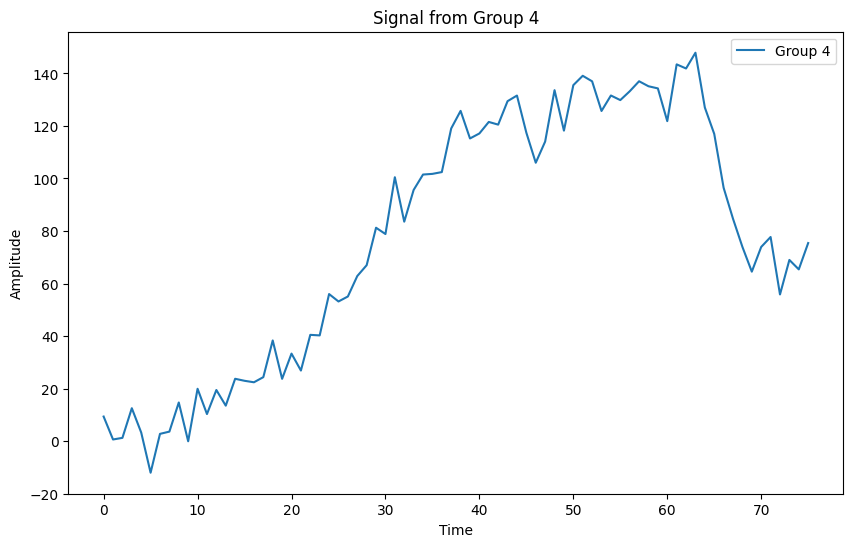

In [10]:
fig = plt.figure(figsize=(10, 6))
plt.plot(group4s[0], label='Group 4')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Signal from Group 4')
plt.legend()
plt.show()



In [6]:
## roughly assign value to placeholder
## normalize and resample data for preprocessing

for i in tqdm(range(0, 1000)):
    X[i,:] = normalize1d(resample(group4s[i], 100))
    y[i,:] = 0

for i in tqdm(range(1000,2000)):
    X[i,:] = normalize1d(resample(group6s[i-1000], 100))
    y[i,:] = 1

for i in tqdm(range(2000,3000)):
    X[i,:] = normalize1d(resample(group2s[i-2000], 100))
    y[i,:] = 2

for i in tqdm(range(3000,4000)):
    X[i,:] = normalize1d(resample(group3s[i-3000], 100))
    y[i,:] = 3

for i in tqdm(range(4000,5000)):
    X[i,:] = normalize1d(resample(group5s[i-4000], 100))
    y[i,:] = 4

for i in tqdm(range(5000,6000)):
    X[i,:] = normalize1d(resample(group7s[i-5000], 100))
    y[i,:] = 5

100%|██████████| 1000/1000 [00:00<00:00, 19310.88it/s]


In [7]:
## split train, validation set

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=0)
sss.get_n_splits(X, y)

1

In [8]:
## get split train, validation index

for i, (train_index, test_index) in enumerate(sss.split(X, y)):
    break

In [9]:
## reshape for model input

X = X.reshape(6000, 100, 1)
y = y.reshape(-1)

In [10]:
## split data

X_train, y_train = X[train_index], y[train_index]
X_valid, y_valid = X[test_index], y[test_index]
print(X_train.shape, X_valid.shape)

(4800, 100, 1) (1200, 100, 1)


In [11]:
## define dataset class for pytorch pipeline

class SignalDataset(Dataset):
    def __init__(self, signals, labels):
        self.signals = signals
        self.labels = labels

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, idx):
        signal = torch.tensor(self.signals[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return signal, label

In [12]:
## define batch size and dataloader for pytorch pipeline

batch_size = 128
train_dataset = SignalDataset(X_train, y_train)
valid_dataset = SignalDataset(X_valid, y_valid)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=True)

In [25]:
## define the device used to train model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")
print(torch.cuda.is_available())

False


In [14]:
## define model

class LSTMSignalClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])  # Take the output from the last time step
        return out

In [15]:
## define model architecture parameters

input_size = 1
hidden_size = 128
num_layers = 3
num_classes = 6
model = LSTMSignalClassifier(input_size, hidden_size, num_layers, num_classes)

In [16]:
## define loss function and optimization function

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [17]:
class EarlyStopping:
    def __init__(self, patience=5, verbose=False, delta=0):
        """
        Args:
            patience (int): How long to wait after last time validation loss improved.
                            Default: 5
            verbose (bool): If True, prints a message for each validation loss improvement.
                            Default: False
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
                            Default: 0
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = float('inf')
        self.delta = delta

    def __call__(self, val_loss, model):

        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decrease.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), 'model/best.pt')
        self.val_loss_min = val_loss

In [18]:
## define how many rounds to train

num_epochs = 200
model.to(device)

LSTMSignalClassifier(
  (lstm): LSTM(1, 128, num_layers=3, batch_first=True)
  (fc): Linear(in_features=128, out_features=6, bias=True)
)

In [19]:
## train pipeline

# Initialize the early stopping object
early_stopping = EarlyStopping(patience=10, verbose=True)

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for signals, labels in train_dataloader:
        signals, labels = signals.to(device), labels.to(device)
        
        outputs = model(signals)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_dataloader)
    
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_predictions = []
    all_probs = []
    with torch.no_grad():
        for signals, labels in valid_dataloader:
            signals, labels = signals.to(device), labels.to(device)
            
            outputs = model(signals)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            probabilities = torch.softmax(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            all_probs.extend(probabilities.cpu().numpy())
    
    val_loss /= len(valid_dataloader)
    val_accuracy = 100 * correct / total
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')

    early_stopping(val_loss, model)

    if early_stopping.early_stop:
        print("Early stopping")
        break

Epoch [1/200], Train Loss: 1.7390, Validation Loss: 1.6633, Validation Accuracy: 29.75%
Validation loss decreased (inf --> 1.663251).  Saving model ...
Epoch [2/200], Train Loss: 1.5379, Validation Loss: 1.3836, Validation Accuracy: 49.25%
Validation loss decreased (1.663251 --> 1.383585).  Saving model ...
Epoch [3/200], Train Loss: 1.5916, Validation Loss: 1.4975, Validation Accuracy: 38.50%
EarlyStopping counter: 1 out of 10
Epoch [4/200], Train Loss: 1.4525, Validation Loss: 1.4544, Validation Accuracy: 38.92%
EarlyStopping counter: 2 out of 10
Epoch [5/200], Train Loss: 1.3744, Validation Loss: 1.2424, Validation Accuracy: 49.42%
Validation loss decreased (1.383585 --> 1.242365).  Saving model ...
Epoch [6/200], Train Loss: 1.0956, Validation Loss: 0.9847, Validation Accuracy: 59.08%
Validation loss decreased (1.242365 --> 0.984662).  Saving model ...
Epoch [7/200], Train Loss: 0.9778, Validation Loss: 0.8859, Validation Accuracy: 70.67%
Validation loss decreased (0.984662 --> 0.8

In [20]:
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report, roc_auc_score,
                             log_loss, matthews_corrcoef, cohen_kappa_score)

In [21]:
precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')

Precision: 0.9775
Recall: 0.9775


In [22]:
accuracy_score(all_labels, all_predictions)

0.9775

In [23]:
f1_score(all_labels, all_predictions, average='weighted')

0.9774357686147003

In [24]:
roc_auc_score(all_labels, all_probs, multi_class='ovr',average='weighted')

0.9986674999999998